# Project Output - Investigation into the Collatz Sequence

This notebook summarises the python code used in our investigation of the Collatz Sequence and focuses on exaplaining our work. It will guide through the main functions we created, how we generated data and what mathematical conclusions we can take from these outputs.

The main sections to this investigation are:
- Standard behaviour of the Collatz sequence
- S2
- Variants of the Collatz Sequence
- The Collatz Tree

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

These are the key python libraries we used in the project, to output data so that we can effectively visualise sequence behaviour.

## Prologue: The Collatz Function

The Collatz sequence is defined below:

$$
f(n) =
\begin{cases}
\frac{n}{2}, & \text{if } n \text{ is even} \\
3n + 1, & \text{if } n \text{ is odd}
\end{cases}
$$

The Collatz conjecture is a famous and unproven conjecture that states that when we repeatedly iterate this function it will eventually reach zero for every positive integer.

This indicates the starting point of our project, with our first tasks being to produce core functions that will define the Collatz sequence in python.

### Function: one Collatz step

```one_step()``` is the first simple function performs one iteration of the Collatz sequence.

This is the fundamental idea that later core functions build upon.

It was later paired with the helper function: ```validate_input()``` as an extra, which rejects invalid inputs.

In [2]:
def validate_input(n):
    '''
    Checks if input is valid (researched how to raise TypeError)
    '''
    
    if type(n)!=int:
        raise TypeError("n must be an integer")
    if n<=0:
        raise ValueError("n must be positive")

In [3]:
def one_step(n):
    '''
    Does one step of the Collatz seq
    '''
    validate_input(n)

    if n%2==0:
        return n//2
    else:
        return 3*n+1

In [4]:
print(one_step(6))
print(one_step(11))

3
34


### Function: The Collatz sequence

The function: ```collatz_sequence()``` repeatdely applies the Collatz rule until we reach 1. Now that we have coded the Collatz sequence we can use this to study it further.

In [5]:
def collatz_sequence(n):
    '''
    Start a Collatz sequence from n
    '''
    validate_input(n)

    seq = [n]

    while seq[-1]!=1:
        seq.append(one_step(seq[-1]))
    return seq

In [6]:
collatz_sequence(21)

[21, 64, 32, 16, 8, 4, 2, 1]

These functions can all be found in the file: ```collatz_functions.py``` along with some of the other core functions from section 1.

## Section 1: Standard behaviour

This section explores coding key properties of an ordinary Collatz sequence and judging its behaviour for different simulations sizes for the first 'N' values of the sequence.

### Properties of the Collatz rule

There are two main properties we wanted to explore for values of the Collatz sequence. These are:

- Stopping time: The number of steps it takes to reach 1.
- Maximum excursion: The highest number the sequence reaches.

Below are the functions ```stopping_time()``` and ```max_excursion()``` respectively.

In [7]:
def stopping_time(n):
    '''
    Number of steps needed to reach 1
    '''

    return len(collatz_sequence(n))-1

In [8]:
def max_excursion(n):
    '''
    Maximum value reached in the sequence
    '''

    return max(collatz_sequence(n))

In [9]:
collatz_sequence(7)

[7, 22, 11, 34, 17, 52, 26, 13, 40, 20, 10, 5, 16, 8, 4, 2, 1]

In [10]:
stopping_time(7)

16

In [11]:
max_excursion(7)

52

### Running simulations of the Collatz sequence

What was next, was to create a function that ran multiple Collatz sequence from 1 to a give value N and store each seperate property in a list.

This involved basic iteration defined in the function ```collatz_simmulations()``` below.

In [12]:
def collatz_simulations(N):
    '''
    Run Collatz simulations for 1<=n<=N.

    Returns three lists:
    - starting values
    - stopping times
    - maximum excursions
    '''

    validate_input(N)

    starting_values = []
    stopping_times = []
    max_values = []

    for n in range(1,N+1):

        starting_values.append(n)
        stopping_times.append(stopping_time(n))
        max_values.append(max_excursion(n))

    return starting_values, stopping_times, max_values

In [13]:
collatz_simulations(10)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [0, 1, 7, 2, 5, 8, 16, 3, 19, 6],
 [1, 2, 16, 4, 16, 16, 52, 8, 52, 16])

### Plotting results for stopping time and maximum excursion

This finally left us to output different results in order to visualise stopping times and maximum excursion as the value of N increased.

This involved defining three functions:
- plot of stopping times
- plot of maximum excursion
- plot of stopping times vs. maximum excursion

You can see the code for this in ```section1_standard_behaviour.py```.

Below allows us to output a summary and the three plots for selected values of N.


-----------------------------
Running for N = 50
Largest stopping time: 111 at n = 27
Largest maximum excursion: 9232 at n = 27
Average stopping time: 21.32
Range of stopping times: 0 to 111
Range of maximum excursions: 1 to 9232


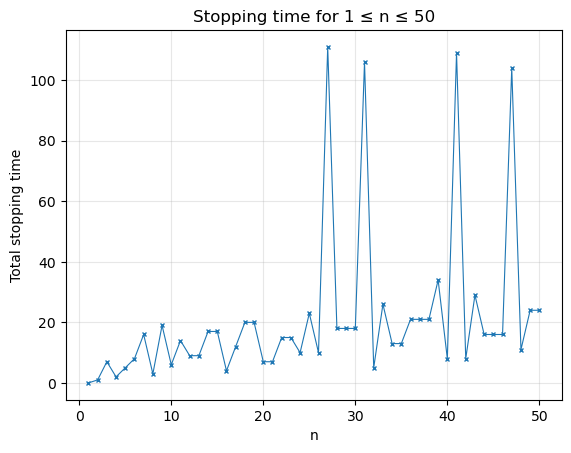

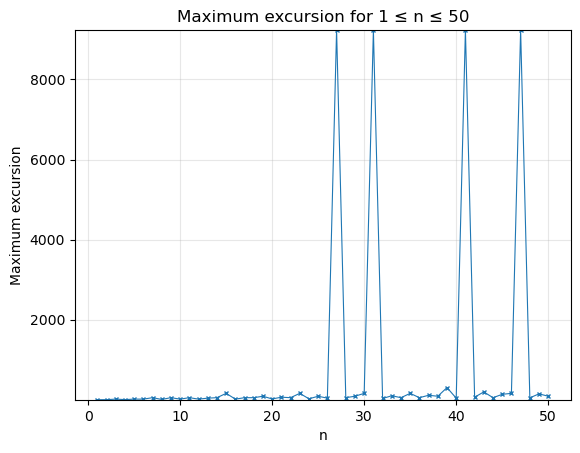

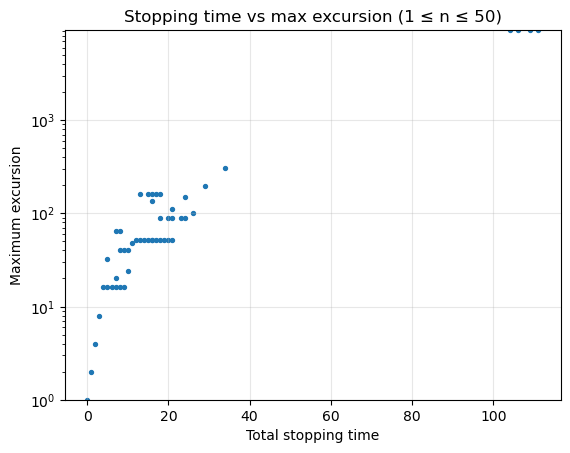


-----------------------------
Running for N = 200
Largest stopping time: 124 at n = 171
Largest maximum excursion: 9232 at n = 27
Average stopping time: 42.09
Range of stopping times: 0 to 124
Range of maximum excursions: 1 to 9232


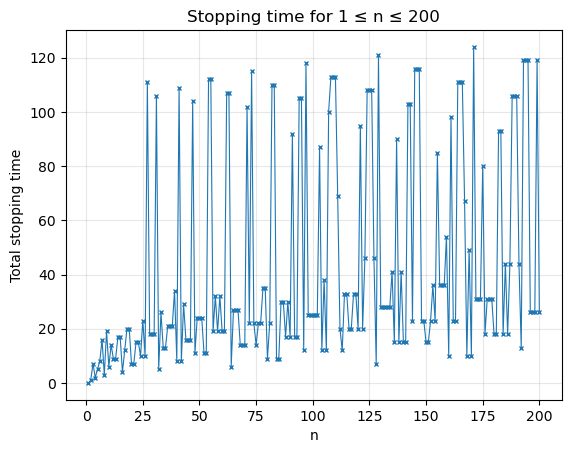

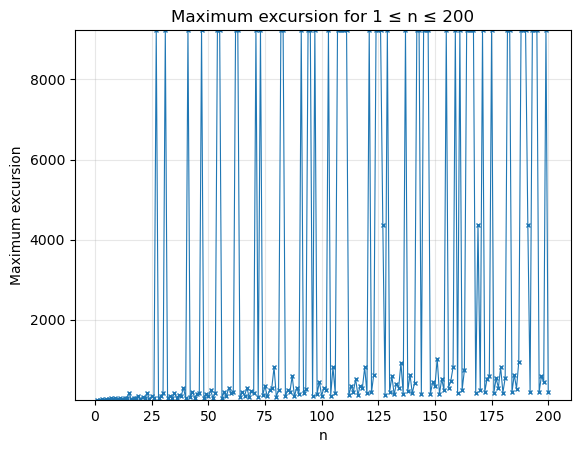

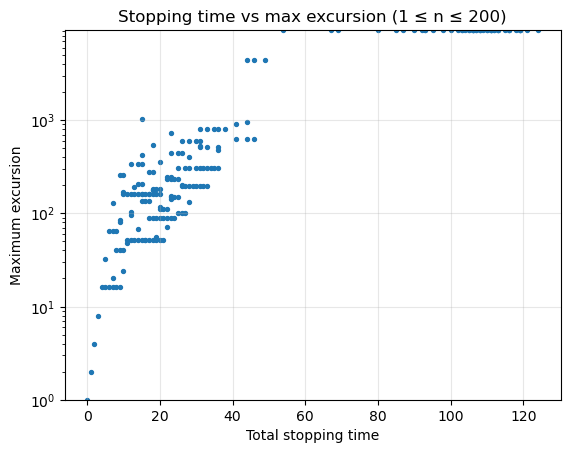

In [18]:
import sections.section1_standard_behaviour


N_values = [50, 200]

for N in N_values:

    print("\n-----------------------------")
    print("Running for N =", N)

    n_val, stop_t, n_exc = collatz_simulations(N)

    # Compute ranges first
    stop_min = min(stop_t)
    stop_max = max(stop_t)

    exc_min = min(n_exc)
    exc_max = max(n_exc)

    # Find where maxima occur
    n_stop = n_val[stop_t.index(stop_max)]
    n_exc_at_max = n_val[n_exc.index(exc_max)]

    print("Largest stopping time:", stop_max, "at n =", n_stop)
    print("Largest maximum excursion:", exc_max, "at n =", n_exc_at_max)

    print("Average stopping time:", round(sum(stop_t)/len(stop_t), 3))
    print("Range of stopping times:", stop_min, "to", stop_max)
    print("Range of maximum excursions:", exc_min, "to", exc_max)

    sections.section1_standard_behaviour.plot_stopping_time(n_val, stop_t, N)
    sections.section1_standard_behaviour.plot_max_excursion(n_val, n_exc, N)
    sections.section1_standard_behaviour.stopping_vs_excursion(stop_t, n_exc, N)